Train shape: (934, 55)
Test shape: (228, 55)
Number of features: 49
Feature columns:
['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'sms', 'screen', 'mood', 'mood_lag1', 'activity_lag1', 'screen_lag1', 'mood_mean_3d_hist', 'activity_mean_3d_hist', 'screen_mean_3d_hist', 'call_mean_3d_hist', 'sms_mean_3d_hist', 'appCat.builtin_mean_3d_hist', 'appCat.communication_mean_3d_hist', 'appCat.entertainment_mean_3d_hist', 'appCat.finance_mean_3d_hist', 'appCat.game_mean_3d_hist', 'appCat.office_mean_3d_hist', 'appCat.other_mean_3d_hist', 'appCat.social_mean_3d_hist', 'appCat.travel_mean_3d_hist', 'appCat.unknown_mean_3d_hist', 'appCat.utilities_mean_3d_hist', 'appCat.weather_mean_3d_hist', 'circumplex.arousal_mean_3d_hist', 'circumplex.valence_mean_3d_hist', 

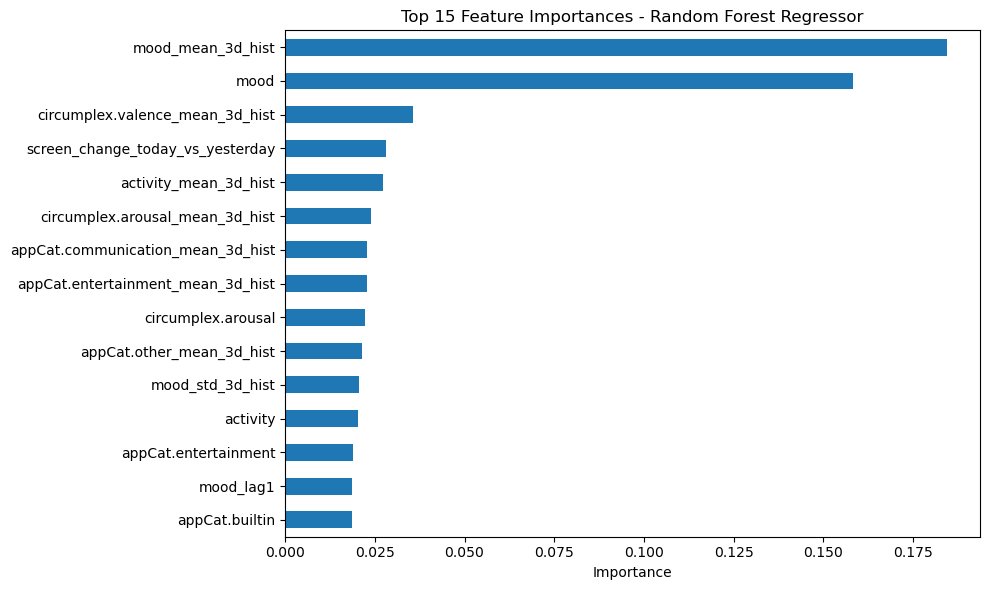

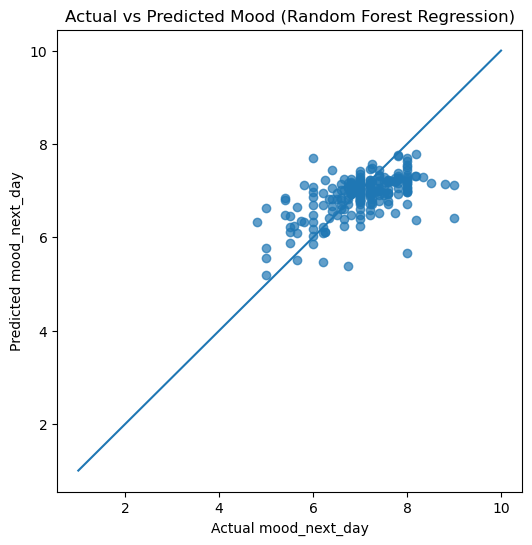

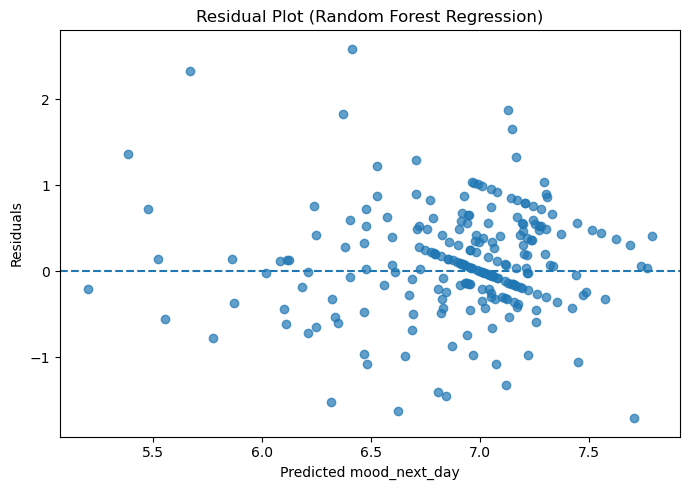

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. Load train and test data
# =========================
train_df = pd.read_csv("data1C/train_data_1C.csv")
test_df = pd.read_csv("data1C/test_data_1C.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# =========================
# 2. Define target and features
# =========================
drop_cols = [
    "id",
    "date",
    "next_date",
    "mood_next_day",
    "is_fake",
    "num_nonzero"
]

X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])

y_train = train_df["mood_next_day"]
y_test = test_df["mood_next_day"]

print("Number of features:", X_train.shape[1])
print("Feature columns:")
print(X_train.columns.tolist())

# =========================
# 3. Define model and hyperparameter grid
# =========================
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# =========================
# 4. Hyperparameter tuning
# =========================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest CV score (negative MAE):", grid.best_score_)
print("Best CV MAE:", -grid.best_score_)
print("Best parameters:", grid.best_params_)

# =========================
# 5. Train final model
# =========================
best_model = grid.best_estimator_

# =========================
# 6. Predict on test set
# =========================
y_pred = best_model.predict(X_test)

# Optional clipping to valid mood range
y_pred_clipped = np.clip(y_pred, 1, 10)

# =========================
# 7. Evaluate
# =========================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest Regression Performance on Test Set:")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R^2 :", round(r2, 4))

# Clipped performance
mae_clipped = mean_absolute_error(y_test, y_pred_clipped)
mse_clipped = mean_squared_error(y_test, y_pred_clipped)
rmse_clipped = np.sqrt(mse_clipped)
r2_clipped = r2_score(y_test, y_pred_clipped)

print("\nClipped Predictions Performance (range 1-10):")
print("MAE :", round(mae_clipped, 4))
print("MSE :", round(mse_clipped, 4))
print("RMSE:", round(rmse_clipped, 4))
print("R^2 :", round(r2_clipped, 4))

# =========================
# 8. Feature importance
# =========================
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 15 most important features:")
print(importances.head(15))

plt.figure(figsize=(10, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Random Forest Regressor")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================
# 9. Plot actual vs predicted
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_clipped, alpha=0.7)
plt.plot([1, 10], [1, 10])
plt.xlabel("Actual mood_next_day")
plt.ylabel("Predicted mood_next_day")
plt.title("Actual vs Predicted Mood (Random Forest Regression)")
plt.show()

# =========================
# 10. Residual plot
# =========================
residuals = y_test - y_pred_clipped

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_clipped, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted mood_next_day")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest Regression)")
plt.tight_layout()
plt.show()